# Stiff ODEs and Implicit Methods
### UT Austin white/albino squirrel campus population
Morgan Gaitz mmg4947

## What are Stiff ODEs?
A system of ODEs is considered stiff when:

It contains processes occurring on vastly different time scales
Explicit methods require extremely small step sizes for stability (even when accuracy doesn't demand it)
Implicit methods can use much larger step sizes while remaining stable
Key characteristic: The stability requirement is much more restrictive than the accuracy requirement.

## Introduction & System Selection 
- Description of your chosen stiff system
- The governing ODEs
- Physical meaning of variables and parameters
- Why this system is important in practice


The UT Austin white/albino squirrel population serves as a good model for stiff ODEs. The campus albino/white squirrel population is controlled by a carrying capacity that shifts with the changing enviroment. The model shows how the population rapidly goes toward this varying carrying capacity. This is what produces stiffness in this model.

- The Governing ODE: dN/dt = - 1000(N(t) - k(t))
- k(t) varies with the function 12(1+.25*sin(.1*t))


why does stiffness matter? 

the population goes towards whatever k(t) in 1/1000 years is but k(t) us conatsnatly ocilating ovwe 10 years. this ratio of rates beinging 10,000 to 1 is what creates this stiffness. Population models with rapid birth/death cycles appear all through the would so understanding them can be applicable in many other settings. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

#universial varibles:
k0=12.0 #intial k (squirrels)
amp=0.25 #how much the carrying capacity oscillates by (no units)
omega=0.1 #frequency (rad/year)
lam=1000 #the population adjustment that makes the eq stiff (1/year)
N0= 3.0 #initialk number od white squirrels

# time - years
start =0 
stop = 20

y0 = np.array([N0]) #inital N


def k(t):
    
    K = k0 * (1 + amp * np.sin(omega * t))
    return K


def dN_dt(t, y):
    
    N = y[0] # population of whit5/albino squirrels at any given year
    K = k(t)
    return np.array([-lam * (N - K)])

def exact_solution(t):
    
    t = np.array(t)

    sin_part = (lam**2 * k0 * amp) / (lam**2 + omega**2)
    cos_part = -(lam * omega * k0 * amp) / (lam**2 + omega**2)

    C = N0 - k0 - cos_part

    N = C * np.exp(-lam * t) + k0 + sin_part * np.sin(omega * t) + cos_part * np.cos(omega * t)

    return N

## Demonstrating Stiffness
- Attempt to solve with Euler's Forward
- Show instability or impractical step size requirements
- Calculate/estimate stiffness ratio
- Explain why implicit methods are necessary

Euler Forward stable step size must be less than: 0.002
Stiffness ratio: 0.0001
h = 0.1 failed at step 4, t = 0.40000
Euler Forward failed for h = 0.1
h = 0.01 failed at step 8, t = 0.08000
Euler Forward failed for h = 0.01
Euler Forward worked for h = 0.001


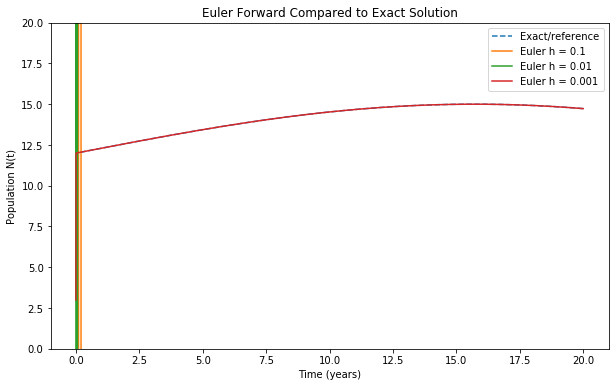

In [2]:
# Eulers Forward - taken from part 1 and then adjusted to meet requirements 
def Euler(step):
    
    num_steps = int(round((stop - start) / step))
    t = np.linspace(start, stop, num_steps + 1)

    #make array to store the population
    y = np.zeros((num_steps + 1, len(y0)))

    #initial condition
    y[0] = y0

    # when / if this method fails
    failed = False
    fail_step = None

    #go through each step
    for i in range(num_steps):
        slope = dN_dt(t[i], y[i])
        y[i + 1] = y[i] + step * slope

        # stop if the solution becomes unrealistic
        # fail if solution blows up
        if not np.isfinite(y[i + 1, 0]) or abs(y[i + 1, 0]) > 1e8:
            failed = True
            fail_step = i + 1
            y[i + 1:, 0] = np.nan
            print(f"h = {step} failed at step {i + 1}, t = {t[i + 1]:.5f}")
            break

    return t, y, failed, fail_step

# calculate stiffness
h_lim = 2 / lam

pop_time = 1 / lam
k_time = 1 / omega
stiffness_ratio = pop_time / k_time

print("Euler Forward stable step size must be less than:", h_lim)
print("Stiffness ratio:", stiffness_ratio)


#look at it at different h values and compare to exact
step_sizes = [0.1, 0.01, 0.001]
solutions = {} # store to graph later

t_exact = np.linspace(start, stop, 5000)
N_exact = exact_solution(t_exact)

plt.figure(figsize=(10, 6))
plt.plot(t_exact, N_exact, '--', label="Exact/reference")

for h in step_sizes:
    
    t, y, failed, fail_step = Euler(h)
    
    solutions[h] = (t, y, failed, fail_step)
    
    plt.plot(t, y[:, 0], label=f"Euler h = {h}")

    if failed:
        print(f"Euler Forward failed for h = {h}")
    else:
        print(f"Euler Forward worked for h = {h}")

plt.xlabel("Time (years)")
plt.ylabel("Population N(t)")
plt.title("Euler Forward Compared to Exact Solution")
plt.ylim(0, 20)
plt.legend()
plt.show()

This graph shows that Euler Forward is unstable for larger step sizes. Since lambda is 1000, the stability condition for Euler Forward is h< 2/1000 = 0.002. The step sizes h=0.1 and h=0.01 are larger than the h limit, so they fail almost immediately and the population values blow up. The step size h=0.001 is smaller than the stability limit, so it stays stable and follows the expected population behavior but extremly computationally exspensive. To simulate 20 years we would need 20,000 steps. This demonstrates stiffness because Euler Forward is forced to use a very small step size even though it is extremely comultationally expensive. 

## Mathematical Setup
- Residual function for your specific problem
- Analytical derivation 
- Newton-Raphson update formula for your specific problem
    
#### derivation
Backward (implicit) Euler advances the state via

$$N_{n+1} = N_n + h\,f(t_{n+1}, N_{n+1}).$$

Because $N_{n+1}$ appears on both sides we rearrange into  $g(N_{n+1}) = 0$:

$$g(N_{n+1}) = N_{n+1} - N_n - h\,f(t_{n+1}, N_{n+1}) = 0.$$

For our linear stiff ODE with $f(t, N) = -\lambda\,(N - K(t))$,

$$g(N_{n+1}) = N_{n+1} - N_n + h\lambda\,(N_{n+1} - K(t_{n+1})), \qquad g'(N_{n+1}) = 1 + h\lambda.$$

The Newton–Raphson update is then

$$N^{(k+1)} = N^{(k)} - \frac{g(N^{(k)})}{g'(N^{(k)})}.$$

Because $g$ is linear in $N$, Newton–Raphson converges in one step. Iterations after that just check the residual against the tolerance. 

In [3]:
#Implement
def G_t(y_guess, y_old, t, h):
    slope =dN_dt(t,y_guess)
    return (y_guess - y_old - h*slope)

def dG_dt(h):
    return 1 +h*lam

def newtom_raph(y_old, t_old, t_new, h, tol=1e-6, max_iter=50):
    
    #first guess -> Euler Forward
    slop = dN_dt(t_old,y_old)
    y_guess = y_old+h*slop
    
    #start adjusting 
    for k in range(max_iter):
        G = G_t(y_guess,y_old,t_new,h)
        
        if abs(G[0]) < tol: #is it with in a reasonable tol?
            return y_guess, k + 1, abs(G[0])
        
        dG = dG_dt(h)
        y_guess[0] = y_guess[0] - G[0] / dG

    G = G_t(y_guess, y_old, t_new, h)
    
    print(y_guess) #debug
    return y_guess, max_iter, abs(G[0])    
    

def EulerBackward(step):

    num_steps = int(round((stop - start) / step))
    t = np.linspace(start, stop, num_steps + 1)

    # make array to store the population
    y = np.zeros((num_steps + 1, len(y0)))

    # stuff for newtonraphson later
    iterations = np.zeros(num_steps)
    final_residuals = np.zeros(num_steps)

    # initial condition
    y[0] = y0

    # go through each step
    for i in range(num_steps):
        
        y[i + 1], iterations[i], final_residuals[i] = newtom_raph(y[i], t[i], t[i + 1], step)


    return t, y, iterations, final_residuals

## Implementation 

- Function defining your ODE
- Derivative (or just use the constant value for linear problems!)
- Newton-Raphson solver
- Euler's Backward method with NR iteration

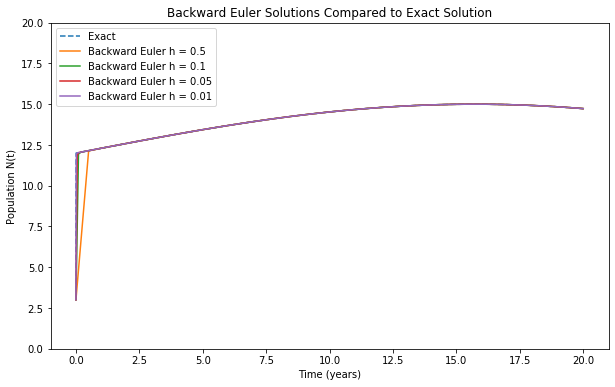

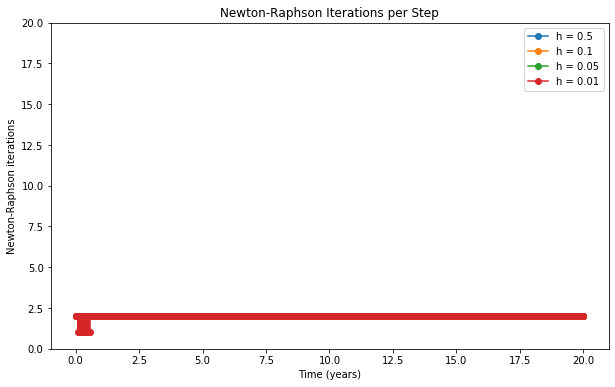

In [4]:
#implement
steps =[.5,0.1,0.05, 0.01]
solutions={}

for h in steps:
    t,y,itera,res = EulerBackward(h)
    solutions[h]=(t,y,itera,res)

plt.figure(figsize=(10, 6))
plt.plot(t_exact, N_exact, '--', label="Exact")

for h in steps:
    t, y, itera, res =solutions[h]
    plt.plot(t,y[:, 0], label=f"Backward Euler h = {h}")

plt.xlabel("Time (years)")
plt.ylabel("Population N(t)")
plt.title("Backward Euler Solutions Compared to Exact Solution")
plt.ylim(0, 20)
plt.legend()
plt.show()



plt.figure(figsize=(10, 6))
for h in steps:
    t, y, itera, res =solutions[h]
    plt.plot(t[1:], itera, marker="o", label=f"h = {h}")

plt.xlabel("Time (years)")
plt.ylabel("Newton-Raphson iterations")
plt.title("Newton-Raphson Iterations per Step")
plt.legend()
plt.ylim(0, 20)
plt.show()

## Results & Analysis 
- Solutions for multiple step sizes
- Comparison plots showing solution behavior
- Newton-Raphson convergence analysis
- Step size stability comparison

,method,step size,number of steps,mean error,max error,final error,average NR iterations
0,Backward Euler,0.50,40,0.000444,0.017964,6.870906e-06,2.000
1,Backward Euler,0.10,200,0.000449,0.089106,1.366139e-06,2.000
2,Backward Euler,0.05,400,0.000449,0.176465,6.825538e-07,2.000
3,Backward Euler,0.01,2000,0.000450,0.817746,1.364279e-07,1.988


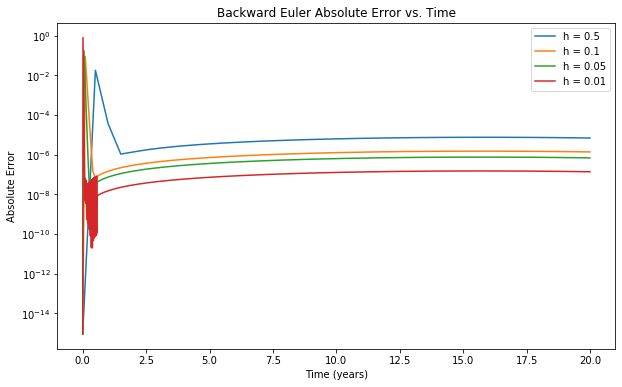

In [5]:
error_data= []

for h in steps:
    
    t, y, itera, res = solutions[h]
    
    #print(t)#debug
    N = exact_solution(t)
    error = abs(y[:, 0] - N)

    error_data.append({
        "method": "Backward Euler",
        "step size": h,
        "number of steps": len(t) - 1,
        "mean error": np.mean(error),
        "max error": np.max(error),
        "final error": error[-1],
        "average NR iterations": np.mean(itera)
    })

error_table = pd.DataFrame(error_data)
display(error_table)

#print("debug")

# plot absolute error over time for each step size
plt.figure(figsize=(10, 6))
for h in steps:
    t, y, itera, res = solutions[h]
    N_ref = exact_solution(t)
    error = abs(y[:, 0] - N_ref)
    plt.semilogy(t, error, label=f"h = {h}")

plt.xlabel("Time (years)")
plt.ylabel("Absolute Error")
plt.title("Backward Euler Absolute Error vs. Time")
plt.legend()
plt.show()




What does this mean in terms of stability?

All step sized tested provided stable solutions. This is a major advantage to implicent methods for this type of problem. The smaller step sized created smaller errors and this was expected. 

## Performance Analysis 
- Computational cost analysis
- Table comparing Euler's Forward vs. Backward
- Discussion of accuracy-efficiency tradeoff
- Practical recommendations

In [6]:
# implement

performance_data = []

# Euler Forward with stable step size
h_forward = 0.001 #the value we found to converge for this method
t_for, y_for, failed_for, fail_step_for = Euler(h_forward)

N_for_exact = exact_solution(t_for)
forward_error = abs(y_for[:, 0] - N_for_exact)

performance_data.append({
    "method": "Euler Forward",
    "step size": h_forward,
    "number of steps": len(t_for) - 1,
    "stable?": "yes",
    "average NR iterations": "-",
    "mean error": np.mean(forward_error),
    "final error": forward_error[-1]
})

# Backward Euler results
for h in steps:
    
    t, y, itera, res = solutions[h]
    
    N_exact_compare = exact_solution(t)
    error = abs(y[:, 0] - N_exact_compare)

    performance_data.append({
        "method": "Backward Euler",
        "step size": h,
        "number of steps": len(t) - 1,
        "stable?": "yes",
        "average NR iterations": np.mean(itera),
        "mean error": np.mean(error),
        "final error": error[-1]
    })

performance_table = pd.DataFrame(performance_data)
display(performance_table)

,method,step size,number of steps,stable?,average NR iterations,mean error,final error
0,Euler Forward,0.001,20000,yes,-,0.000262,1.364050e-08
1,Backward Euler,0.500,40,yes,2,0.000444,6.870906e-06
2,Backward Euler,0.100,200,yes,2,0.000449,1.366139e-06
3,Backward Euler,0.050,400,yes,2,0.000449,6.825538e-07
4,Backward Euler,0.010,2000,yes,1.988,0.000450,1.364279e-07


so what does this mean?

when h =.5 using Eulers Backwards it only take 40 steps to simulate all 40 years and have a stable solution. Eulers Forwards needs 20,000 steps and a h = .001 to find a stable solution. This is a major advantage of Backwards Eulers with Newron Raphson. Additionally, Eulers Forward takes alot of communtational effor but doesnt imporove accuracy.. Eulers backwards creates a good nbalance of accuracy and effeciency. For stiff problems like this, it is recommended to use an implicnt method liek Eulers backwards with Newton Raphson because of its accuract and effiency. 

## Conclusions 
Summary of key findings
When to use implicit vs. explicit methods
Challenges encountered and lessons learned

key take aways:

this first key take away from this model is that stiffness is measuable. The stiffness ratio is a value that can help gage what kind of method would work best, if the ration is large its best to use a impleicnt method to solve as it can handle stiff equations significantly better. Another big take away is the  accuracy-effeicny trade off, Eulers forwards is extremely simple but time complex for stiff equations and builds error.The main challenge in this problem was understanding the equation itself. There are a lot of moving parts and varibles that make the equation complicated to understand. Additionally figuring out the best way to reprsent the results was difficult. This is a complicated concept to understand and even more complicated to simply for others to understand. 

## AI citations

Claude was used for every prompt
- Break this project into digestible steps to follow. This is a lot of moving parts and I am not sure where to start or how things should work together. What is the best outline and flow? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached instructions)
    - Why- I was very overwhelmed and needed help to break down the concepts and understand the problem before I could get started. 

- What does this equation mean? What makes it a stiff ODE? How would I implement it as a function? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached the population equation)
    - Why- I needed clarification on what exactly i was looking for in this project and how to represent the equation with a function. 

- What variable makes most sense for this specific scenario? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current code and instructions)
    - Why- i didnt understand what would make sense for the white/albino squirrel scenario for things like omega, k0 and amplitude. 

- What h value makes Euler's forward stable? How do I calculate stiffness? What is a stiffness ratio and what does it tell me? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current code and instructions)
    - Why- I needed help understanding how to demonstrate stiffness and find stability in this case. 

- What is the mathematical set up for implementing Euler's backwards? After implementing it, what is the best way to analyze and compare the output? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current code and instructions)
    - Why- before applying the concept i wanted to get a complete grasp on what i am looking for and where these equations were coming from

- What is the exact solution to this Stiff ODE? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding.  (attached population equation being solved and current code)
    - Why- the exact solution is extremely complicated to solve due to the many moving parts and complicated stiff ODE. 

- What does these graphs mean and why do they look wrong? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current code, graph outputs, and instructions)
    - Why - I got outputs didnt know what made sense to be the output and if my results were correct. If they were wrong or off, all of my analysis would not make sense and I likely have a logic error that would affect the entire project.

- How do I create a table to represent the error data at each step size?
    - Why: There were a lot of numbers I needed to calculate but I had never made a table in python before this project 

- Re-write my mathematical set up section to be formatted ina more readable way using actual meth notations. (attached current code and instruction file)
    - Why-  I didnt know how to format what i wanted to represent properly.

- Am I missing anything to receive full credit on this project? How can the written analysis paragraphs be improved to flow better? Do the comments left on the code make it clear what is happening in the code to produce the output? (attached current code and instruction file)
    - Why: doing final touches and wanted to make sure I wasn't missing anything important. 

- Put these into APA format (attached all links)
	- Why: needed help formatting the sources i found 



## Sources

Academic Programs for Undergraduates. (n.d.). The legend of the albino squirrel. The University of Texas at Austin. https://undergraduates.utexas.edu/legend-albino-squirrel

Clark, M. A., Douglas, M., & Choi, J. (2018, March 28). Environmental limits to population growth. In Biology 2e. OpenStax. https://openstax.org/books/biology-2e/pages/45-3-environmental-limits-to-population-growth

Kaw, A. (n.d.). Newton-Raphson method for solving a nonlinear equation. In Numerical methods with applications. Mathematics LibreTexts. https://math.libretexts.org/Workbench/Numerical_Methods_with_Applications_%28Kaw%29/3%253A_Nonlinear_Equations/3.04%253A_Newton-Raphson_Method_for_Solving_a_Nonlinear_Equation

The pandas development team. (n.d.). Table visualization. In pandas 3.0.2 documentation. https://pandas.pydata.org/docs/user_guide/style.html

Texas Parks and Wildlife Department. (n.d.). Eastern fox squirrel (Sciurus niger). https://tpwd.texas.gov/huntwild/wild/species/easternfoxsquirrel/
